In [1]:
# imports
import gymnasium as gym
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager

In [2]:
# import the frozen lake gym environment
name = 'FrozenLake-v1'
env = gym.make(name, is_slippery=False) # warning: setting slippery=True results in very complex environment dynamics where the optimal solution does not make sense to humans!
seed=742

obs, info = env.reset(seed=seed)
env.action_space.seed(seed)
rng = np.random.default_rng(seed)

# lets examine it
print('action space: ' + str(env.action_space))
print('reward range: ' + str(env.reward_range) if hasattr(env, "reward_range") else "(0,1)")
print('observation space: ' + str(env.observation_space))
env.render()

action space: Discrete(4)
reward range: (0, 1)
observation space: Discrete(16)


/home/coder/ikt460-lab-assignments/.venv/lib/python3.13/site-packages/gymnasium/envs/toy_text/frozen_lake.py:328: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("FrozenLake-v1", render_mode="rgb_array")
  gym.logger.warn(


In [3]:
# actions
LEFT, DOWN, RIGHT, UP = 0,1,2,3

# lets do an example step for the policy
env.reset()
next_state, reward, terminated, truncated, info = env.step(DOWN) # s_next, r, terminated, truncated, info 
print('=============')
print('next state: ' + str(next_state))
print('terminated: ' + str(terminated))
print('truncated: ' + str(truncated))
print('    reward: ' + str(reward))
print('      info: ' + str(info))

next state: 4
terminated: False
truncated: False
    reward: 0.0
      info: {'prob': 1.0}


In [4]:
# helper function to draw the frozen lake
def plot(V,policy,col_ramp=1,dpi=175,draw_vals=False):
    plt.rcParams['figure.dpi'] = dpi
    plt.rcParams.update({'axes.edgecolor': (0.32,0.36,0.38)})
    plt.rcParams.update({'font.size': 4 if env.unwrapped.nrow == 8 else 7})
    plt.figure(figsize=(3,3))
    plt.imshow(1-V.reshape(env.unwrapped.nrow,env.unwrapped.ncol)**col_ramp, cmap='gray', interpolation='none', clim=(0,1))
    ax = plt.gca()
    ax.set_xticks(np.arange(env.unwrapped.ncol)-.5)
    ax.set_yticks(np.arange(env.unwrapped.nrow)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    for s in range(env.observation_space.n):
        x = s%env.unwrapped.nrow
        y = int(s/env.unwrapped.ncol)
        a = policy[s]
        gray = np.array((0.32,0.36,0.38))
        if env.unwrapped.desc.tolist()[y][x] == b'G':
            plt.text(x-0.45,y-0.3, 'goal', color=(0.75,0.22,0.17), fontname='DejaVu Sans', weight='bold')
            continue
        if a[0] > 0.0: plt.arrow(x, y, float(a[0])*-.84, 0.0, color=gray+0.2*(1-V[s]), head_width=0.1, head_length=0.1) # left
        if a[1] > 0.0: plt.arrow(x, y, 0.0, float(a[1])*.84,  color=gray+0.2*(1-V[s]), head_width=0.1, head_length=0.1) # down
        if a[2] > 0.0: plt.arrow(x, y, float(a[2])*.84, 0.0,  color=gray+0.2*(1-V[s]), head_width=0.1, head_length=0.1) # right
        if a[3] > 0.0: plt.arrow(x, y, 0.0, float(a[3])*-.84, color=gray+0.2*(1-V[s]), head_width=0.1, head_length=0.1) # up
        if env.unwrapped.desc.tolist()[y][x] == b'F': plt.text(x-0.45,y-0.3, 'ice', color=(gray*V[s]), fontname='DejaVu Sans')
        if env.unwrapped.desc.tolist()[y][x] == b'S': plt.text(x-0.45,y-0.3, 'start',color=(0.21,0.51,0.48), fontname='DejaVu Sans', weight='bold')
        if draw_vals and V[s]>0:
            vstr = '{0:.1e}'.format(V[s]) if env.unwrapped.nrow == 8 else '{0:.6f}'.format(V[s])
            plt.text(x-0.45,y+0.45, vstr, color=(gray*V[s]), fontname='DejaVu Sans')
    plt.grid(color=(0.42,0.46,0.48), linestyle=':')
    ax.set_axisbelow(True)
    ax.tick_params(color=(0.42,0.46,0.48),which='both',top='off',left='off',right='off',bottom='off')
    plt.show()

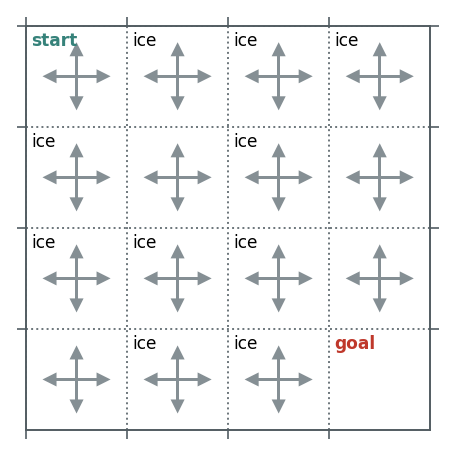

In [7]:
# lets start with a random policy, in this case there's a 1/4 probability of taking any action at every 4x4 state
policy = np.ones([env.observation_space.n, env.action_space.n]) / env.action_space.n

#plot(V,policy,1.0,draw_vals=True)
plot(V=np.zeros(env.observation_space.n),policy=policy,col_ramp=1.0,draw_vals=True)

In [8]:

# ---------------------------
# First-Visit Monte Carlo
# ---------------------------
nS = env.observation_space.n
nA = env.action_space.n
gamma = 0.99
print('nS,nA',nS,nA)

# Start with a uniform stochastic policy π(a|s) = 1/nA
policy = np.ones((nS, nA)) / nA

# Action-value function Q(s,a) and running counts for FV-MC sample averages
Q = np.zeros((nS, nA), dtype=np.float64)
N = np.zeros((nS, nA), dtype=np.int32)  # first-visit counts

def epsilon_greedy_from_Q(Q, eps):
    """Build an ε-greedy policy matrix from Q."""
    nS, nA = Q.shape
    pi = np.full((nS, nA), eps / nA, dtype=np.float64)
    best_actions = np.argmax(Q, axis=1)
    pi[np.arange(nS), best_actions] += (1.0 - eps)
    return pi

def generate_episode(env, policy, rng):
    """Generate one episode following the (stochastic) policy matrix."""
    episode = []  # list of (s, a, r)
    s, info = env.reset()
    done = False
    while not done:
        # sample action from policy[s]
        a = rng.choice(np.arange(nA), p=policy[s])
        s_next, r, terminated, truncated, info = env.step(a)
        episode.append((s, a, r))
        s = s_next
        done = terminated or truncated
    return episode

def first_visit_mc_control(env, num_episodes=5000, eps_start=1.0, eps_end=0.05, eps_decay=0.995, print_every=500):
    global Q, N, policy
    eps = eps_start
    for ep in range(1, num_episodes + 1):
        # (1) Generate episode using current π
        episode = generate_episode(env, policy, rng)

        # (2) First-visit returns and Q update via sample average
        visited = set()
        # Compute returns G_t for each t (naive O(T^2) for clarity; T is small in FrozenLake)
        T = len(episode)
        # Precompute returns-from-t for speed
        returns_from_t = np.zeros(T, dtype=np.float64)
        G = 0.0
        for t in reversed(range(T)):
            _, _, r = episode[t]
            G = gamma * G + r
            returns_from_t[t] = G

        for t, (s, a, r) in enumerate(episode):
            if (s, a) in visited:
                continue  # first-visit only
            visited.add((s, a))
            G_t = returns_from_t[t]
            N[s, a] += 1
            # incremental mean
            Q[s, a] += (G_t - Q[s, a]) / N[s, a]

        # (3) Policy improvement to ε-greedy wrt new Q
        policy = epsilon_greedy_from_Q(Q, eps)

        # decay epsilon
        eps = max(eps_end, eps * eps_decay)

        if print_every and (ep % print_every == 0 or ep == 1):
            V = Q.max(axis=1)
            print(f"Episode {ep:5d} | epsilon={eps:.3f} | mean V={V.mean():.4f}")

    return Q, policy


nS,nA 16 4


Episode     1 | epsilon=0.995 | mean V=0.0000
Episode   500 | epsilon=0.082 | mean V=0.4865
Episode  1000 | epsilon=0.050 | mean V=0.5167
Episode  1500 | epsilon=0.050 | mean V=0.5286
Episode  2000 | epsilon=0.050 | mean V=0.5391
Episode  2500 | epsilon=0.050 | mean V=0.5424
Episode  3000 | epsilon=0.050 | mean V=0.5469
Episode  3500 | epsilon=0.050 | mean V=0.5490
Episode  4000 | epsilon=0.050 | mean V=0.5509
Episode  4500 | epsilon=0.050 | mean V=0.5525
Episode  5000 | epsilon=0.050 | mean V=0.5542
Greedy policy w.r.t. Q (argmax probabilities):
[[1 0 1 0]
 [1 0 1 0]
 [2 2 1 0]
 [0 2 2 0]]


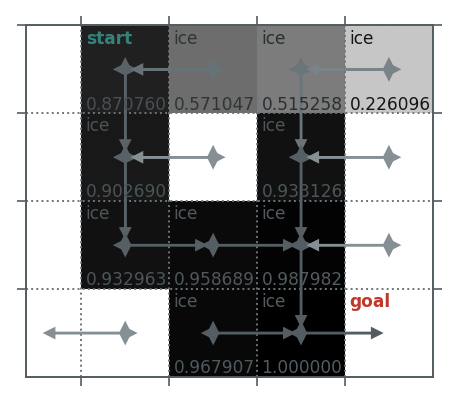

In [9]:

# ---------------------------
# Train and visualize
# ---------------------------
Q, policy = first_visit_mc_control(
    env,
    num_episodes=5000,  # increase to ~20k if is_slippery=True
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.995,
    print_every=500
)

V = Q.max(axis=1)
print("Greedy policy w.r.t. Q (argmax probabilities):")
print(np.argmax(policy, axis=1).reshape(env.unwrapped.nrow,env.unwrapped.ncol))
plot(V, policy, 1.0,draw_vals=True)


In [10]:

# ---------------------------
# Quick evaluation run (greedy policy)
# ---------------------------
def evaluate_policy(env, policy, episodes=200):
    wins = 0
    for _ in range(episodes):
        s, info = env.reset()
        done = False
        while not done:
            a = np.argmax(policy[s])  # greedy
            s, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated
            if done and r > 0:
                wins += 1
    return wins / episodes

greedy_win_rate = evaluate_policy(env, policy, episodes=200)
print(f"Greedy success rate over 200 evaluation episodes: {greedy_win_rate:.2%}")


Greedy success rate over 200 evaluation episodes: 100.00%
